In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Dane do Zadania 1: Szeregi czasowe (Direct Labeling)
years = np.arange(2015, 2026)
prod_A = 100 + 5 * (years - 2015) + np.random.normal(0, 3, len(years))
prod_B = 120 + 2 * (years - 2015) + np.random.normal(0, 4, len(years))
prod_C = 80 + 8 * (years - 2015) + np.random.normal(0, 5, len(years))

# Dane do Zadania 2: Porównanie dwóch punktów w czasie (Slopegraph)
countries =['Polska', 'Czechy', 'Słowacja', 'Węgry', 'Litwa']
data_2015 =[50, 65, 60, 55, 45]
data_2025 =[75, 70, 65, 50, 60]

# Dane do Zadania 3 (Pie Chart)
pie_labels =['Azja', 'Europa', 'Ameryka Płn.', 'Ameryka Płd.', 'Afryka']
pie_values =[45, 25, 15, 10, 5] # Tufte zaleca sortowanie danych od największych

# Dane do Zadania C (Small Multiples)
years_sm = np.arange(2010, 2021)
stock_A = np.cumsum(np.random.normal(1, 2, len(years_sm))) + 50
stock_B = np.cumsum(np.random.normal(-0.5, 3, len(years_sm))) + 50
stock_C = np.cumsum(np.random.normal(2, 1.5, len(years_sm))) + 50
stock_D = np.cumsum(np.random.normal(-1, 2.5, len(years_sm))) + 50

## 1. Make-over: Eliminacja Legendy (Direct Labeling)
*(Inspiracja: Tufte, unikanie zbędnego ruchu gałek ocznych i kodowania)*

Tradycyjne wykresy wieloliniowe posiadają ramkę legendy. Tufte zauważa, że zmusza to oko widza do ciągłego skakania między krzywymi a legendą, aby "zdekodować" kolory. Ramka legendy to czysty "non-data-ink". Zamiast tego, nazwy serii powinny być umieszczone **bezpośrednio na wykresie**, na końcach linii.

**Instrukcja krok po kroku:**
1. Na `ax1` narysuj standardowy wykres z kolorowymi liniami i legendą (`ax1.plot(..., label='...')` oraz `ax1.legend()`). Włącz siatkę.
2. Na `ax2` narysuj te same 3 linie, ale użyj wyłącznie czarnego koloru (`color='black'`). Zróżnicuj je argumentem `linestyle`: użyj `'-'` (ciągła), `'--'` (przerywana) oraz `':'` (kropkowana).
3. Usuń górną i prawą ramkę na `ax2` (`ax2.spines['...'].set_visible(False)`).
4. Zastosuj *Range-frame*: oblicz minimum i maksimum dla osi X (skrajne lata) oraz globalne minimum i maksimum dla osi Y. Następnie użyj `ax2.spines['...'].set_bounds(min, max)` dla dolnej i lewej ramki.
5. **Nie dodawaj legendy!** Użyj funkcji `ax2.text(x, y, s)`, aby podpisać każdą z linii w kolorze czarnym.
6. Aby wykres był czytelny: rozszerz limity osi X (`set_xlim`) dodając margines na tekst po prawej oraz **lekki margines po lewej** (np. `x_min - 0.5`), aby linie nie przyklejały się do osi Y.
7. Wymuś znaczniki na osi X tak, aby nie wykraczały poza uciętą oś (`set_xticks`).

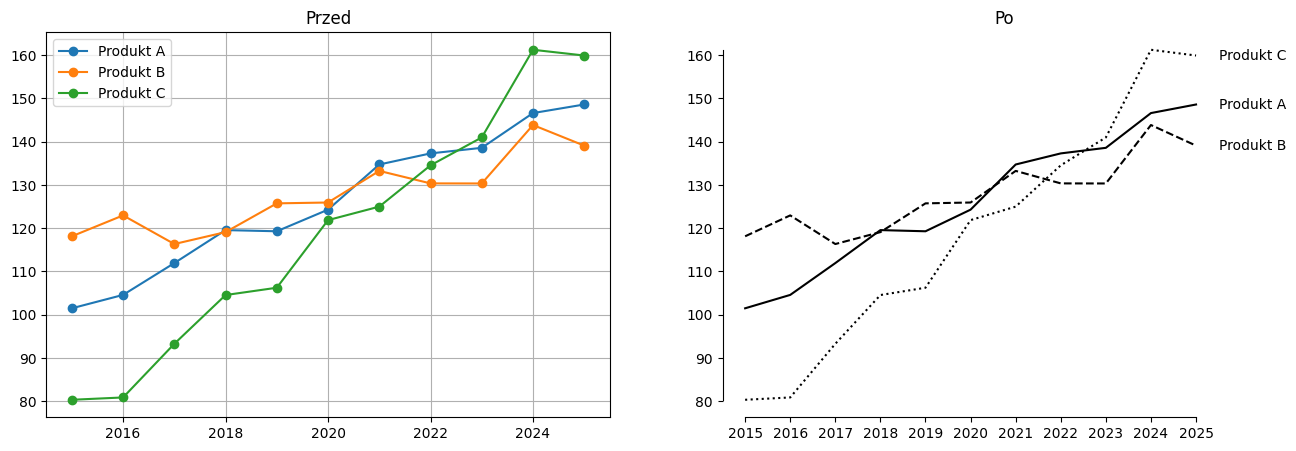

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=100)
ax1.plot(years, prod_A, years, prod_B, years, prod_C, marker='o')
ax1.legend(['Produkt A', 'Produkt B', 'Produkt C'])
ax1.grid()
ax1.set_title('Przed');
ax2.plot(years, prod_A, color='black', linestyle = '-')
ax2.plot(years, prod_B, color='black', linestyle = '--')
ax2.plot(years, prod_C, color='black', linestyle = ':')
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
x_min = min(years)
x_max = max(years)
ax2.spines['bottom'].set_bounds(x_min, x_max)
all_prod_values = np.concatenate((prod_A, prod_B, prod_C))
y_min = np.min(all_prod_values)
y_max = np.max(all_prod_values)
ax2.spines['left'].set_bounds(y_min, y_max)
ax2.set_xlim(x_min - 0.5, x_max + 2)
ax2.set_xticks(years)
ax2.text(years[-1] + 0.5, prod_A[-1], 'Produkt A', color='black', ha='left', va='center');
ax2.text(years[-1] + 0.5, prod_B[-1], 'Produkt B', color='black', ha='left', va='center');
ax2.text(years[-1] + 0.5, prod_C[-1], 'Produkt C', color='black', ha='left', va='center');
ax2.set_title('Po');

## 2. Make-over: Slopegraph zamiast Grupowanych Słupków
*(Inspiracja: Tufte - The Visual Display of Quantitative Information)*

Aby porównać dwie zmienne w czasie dla kilku kategorii, programy statystyczne domyślnie tworzą potężne, zgrupowane wykresy słupkowe. Mnóstwo na nich kolorów, grubych bloków, legend i osi. Tufte wymyślił tzw. **Slopegraph** (wykres nachylenia). Eliminuje on całkowicie osie! Zostają tylko nazwy, liczby i łączące je linie. Nachylenie natychmiast komunikuje kierunek i siłę zmiany.

**Instrukcja krok po kroku:**
1. Na `ax1` wygeneruj zgrupowany wykres słupkowy (jest już w szkielecie kodu, ponieważ jest dość żmudny do napisania od zera).
2. Na `ax2` będziemy rysować Slopegraph. Użyj pętli `for i in range(len(countries)):`
3. Wewnątrz pętli narysuj linię łączącą punkt X=0 (rok 2015) z punktem X=1 (rok 2025). Użyj `ax2.plot([0, 1],[data_2015[i], data_2025[i]], color='black', marker='o')`.
4. Nadal w pętli, dodaj tekst po lewej stronie wykresu za pomocą `ax2.text()`. Współrzędne to X=`-0.05` i Y=`data_2015[i]`. Treść to `f'{countries[i]} {data_2015[i]}'`. Ustaw wyrównanie do prawej: `ha='right'`, `va='center'`.
5. Dodaj tekst po prawej stronie dla wartości z 2025: współrzędne X=`1.05`, Y=`data_2025[i]`. Treść to `f'{data_2025[i]}'`. Ustaw wyrównanie: `ha='left'`, `va='center'`.
6. Poza pętlą: usuń całkowicie układ współrzędnych i ramki za pomocą magicznej komendy `ax2.axis('off')`.
7. Ustaw nagłówki kolumn (jako teksty): nad rokiem 2015 (X=`0`) oraz rokiem 2025 (X=`1`).
8. Skoryguj limity osi X (`ax2.set_xlim(-0.5, 1.5)`), by napisy się zmieściły.

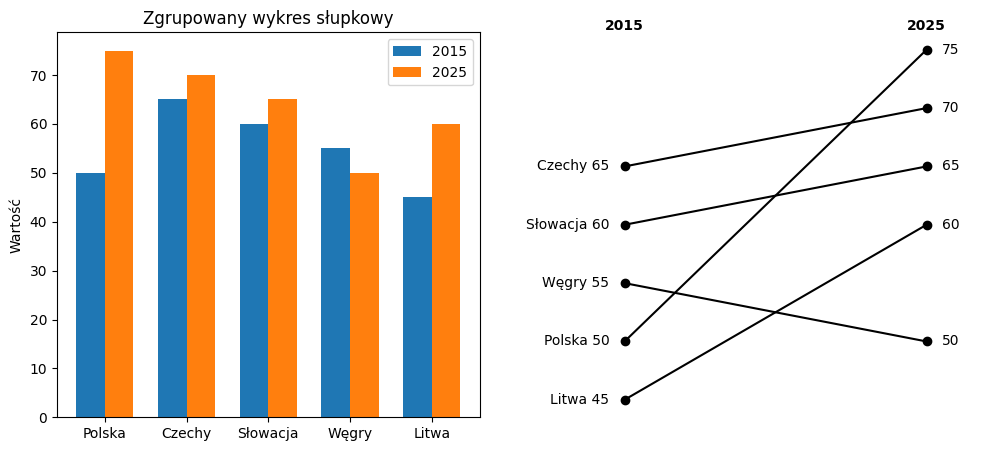

In [51]:
# wcale nie ma nic w szkielecie kodu
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
x = np.arange(len(countries))
width = 0.35
ax1.bar(x - width/2, data_2015, width, label='2015')
ax1.bar(x + width/2, data_2025, width, label='2025')
ax1.set_xticks(x)
ax1.set_xticklabels(countries)
ax1.set_ylabel('Wartość')
ax1.set_title('Zgrupowany wykres słupkowy')
ax1.legend()

for i in range(len(countries)):
  ax2.plot([0, 1],[data_2015[i], data_2025[i]], color='black', marker='o')
  ax2.text(-0.05, data_2015[i], f'{countries[i]} {data_2015[i]}', ha='right', va='center')
  ax2.text(1.05,data_2025[i], f'{data_2025[i]}', ha='left', va='center')
ax2.axis('off');
ax2.text(0,77, '2015', fontweight='bold', ha='center', va='center')
ax2.text(1,77, '2025', fontweight='bold', ha='center', va='center')
ax2.set_xlim(-0.2, 1.2);


## 3. Make-over: Śmierć Wykresu Kołowego (Pie Chart vs. Horizontal Bar)
*(Inspiracja: Tufte, str. 178)*

Edward Tufte jest znany ze swojej nienawiści do wykresów kołowych. W swojej książce pisze wprost: *"Tabela jest niemal zawsze lepsza niż głupi wykres kołowy; jedynym gorszym projektem od wykresu kołowego jest kilka wykresów kołowych"*. Wykresy kołowe mają fatalny *Data-Ink Ratio*, wymagają kodowania kolorami i zmuszają oko do oceny kątów, w czym ludzki mózg jest bardzo słaby.

Zamienimy "kolorowy placek" na elegancki, poziomy wykres słupkowy, który integruje etykiety bezpośrednio w sobie.

**Instrukcja krok po kroku:**
1. Na `ax1` wygeneruj wykres kołowy za pomocą `ax1.pie(pie_values, labels=pie_labels, autopct='%1.1f%%')`.
2. Na `ax2` użyj `ax2.barh(pie_labels, pie_values, color='lightgray')`. (Używamy `barh`, aby etykiety tekstu były poziome i łatwe do czytania).
3. Na `ax2` usuń **wszystkie 4 ramki** (`spines`) - dokładnie tak, jak robiliśmy to we wcześniejszych zadaniach.
4. Usuń dolną oś i wszystkie "wąsy" osi: `ax2.tick_params(bottom=False, left=False, labelbottom=False)`. Zostawiamy `labelleft=True`, aby nazwy kontynentów były widoczne.
5. Dodaj wartości bezpośrednio na końcach słupków! Użyj pętli `for i, v in enumerate(pie_values):` i wstaw tekst: `ax2.text(v + 1, i, f"{v}%", va='center', fontweight='bold')`.

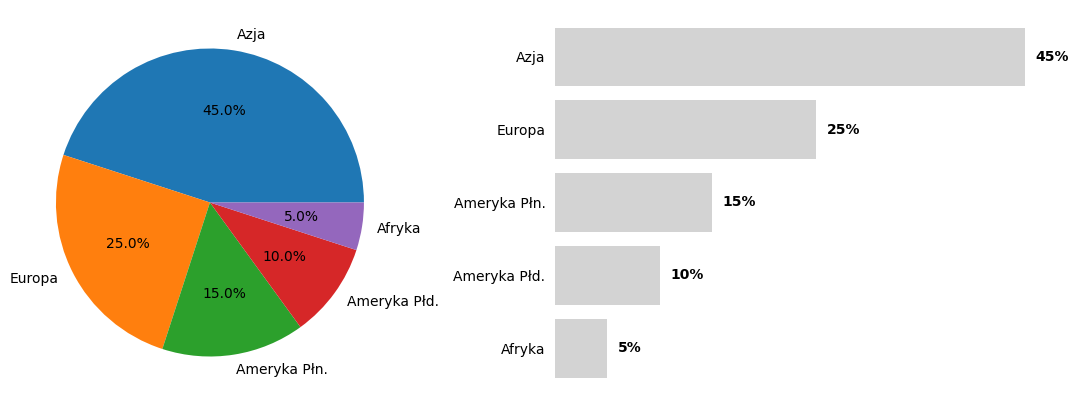

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
ax1.pie(pie_values, labels=pie_labels, autopct='%1.1f%%')
ax2.barh(pie_labels, pie_values, color='lightgray')
for i in ['top', 'right', 'left', 'bottom']:
  ax2.spines[i].set_visible(False)
ax2.tick_params(bottom=False, left=False, labelbottom=False)
for i, v in enumerate(pie_values):
  ax2.text(v + 1, i, f"{v}%", va='center', fontweight='bold')
ax2.invert_yaxis()

## Zadanie dodatkowe dla szybkich i chętnych :)

### C. Zjawisko Małych Wielokrotności (Small Multiples)
*(Inspiracja: Tufte, str. 170-175)*

Gdy na jednym wykresie liniowym umieścimy zbyt wiele serii danych (np. 4 różne spółki), linie zaczynają się przecinać, tworząc nieczytelne "spaghetti". Konieczna jest też duża legenda.
Tufte rozwiązuje to przez **Small Multiples (Małe Wielokrotności)** – dzieli jeden duży wykres na siatkę małych, minimalistycznych wykresów (jeden dla każdej serii), które *współdzielą dokładnie tę samą skalę*.

**Instrukcja krok po kroku:**
1. Zamiast standardowych 2 subplotów, tym razem kod używa układu 1x5 (`plt.subplots(1, 5)`). Pierwszy wykres to nasze "spaghetti", cztery kolejne to nasze *Small Multiples*.
2. Przeanalizuj pętlę w kodzie poniżej. Zauważ, że usuwamy zbędne ramki i wyłączamy siatkę, zostawiając wyłącznie **jedną referencyjną poziomą linię** (punkt startowy 50) za pomocą `ax.axhline(50, color='lightgray')`.
3. Aby "Małe Wielokrotności" miały sens, **muszą współdzielić oś Y**. Zwróć uwagę na użycie `ax.set_ylim(20, 80)` na każdym subplocie!
4. Zamiast legendy, każdy mały wykres ma po prostu tytuł z nazwą spółki.

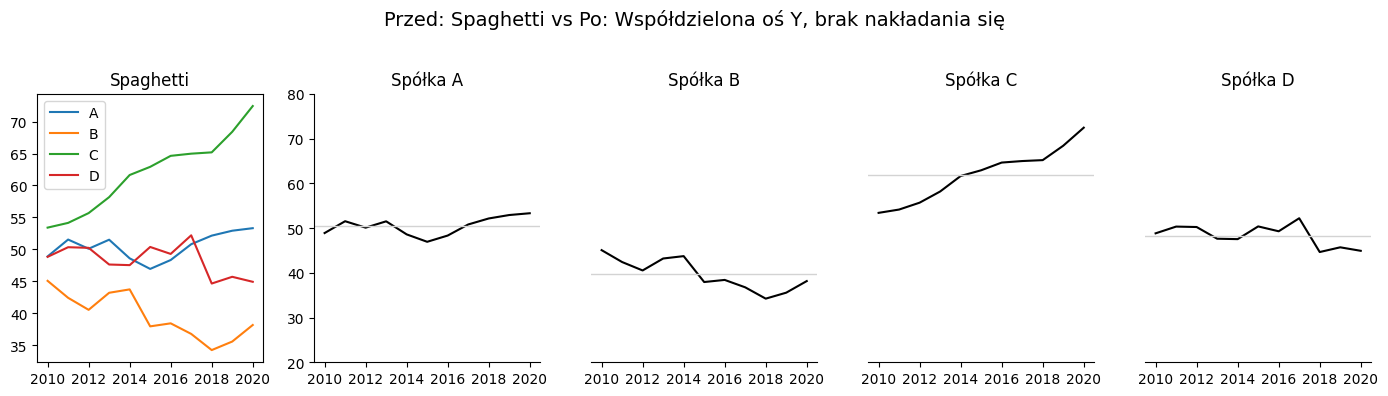

In [17]:
fig, gs = plt.subplots(1, 5,figsize=(14, 4), dpi=100)

stocks = {
    "Spółka A": stock_A,
    "Spółka B": stock_B,
    "Spółka C": stock_C,
    "Spółka D": stock_D
}

ax0 = gs[0]

ax0.plot(years_sm, stock_A, label='A')
ax0.plot(years_sm, stock_B, label='B')
ax0.plot(years_sm, stock_C, label='C')
ax0.plot(years_sm, stock_D, label='D')

ax0.set_title("Spaghetti")
ax0.legend()
ax0.set_xticks(years_sm[::2])

axes = []
for i, (name, data) in enumerate(stocks.items()):
    ax = fig.add_subplot(gs[i+1], sharey=ax0)
    ax.plot(years_sm, data, color='black')
    ax.set_title(name)
    ax.set_ylim(20, 80)

    ax.axhline(np.mean(data), color='lightgray', linewidth=1)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if i !=0:
      ax.spines['left'].set_visible(False)
      ax.tick_params(axis='y', length=0)
      ax.tick_params(labelleft=False)
    ax.set_xticks(years_sm[::2])

    axes.append(ax)

fig.suptitle("Przed: Spaghetti vs Po: Współdzielona oś Y, brak nakładania się", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])